In [2]:
import wave
import os

RAW_DIR = 'audio_files/raw_dir/'
WAV_DIR = 'audio_files/wav_dir/'

# Ensure the output directory exists just in case
os.makedirs(WAV_DIR, exist_ok=True)

# Loop through all files in the RAW_DIR
for filename in os.listdir(RAW_DIR):
    if filename.endswith(".raw"):
        raw_filepath = os.path.join(RAW_DIR, filename)
        
        # Create the corresponding .wav filename
        wav_filename = filename.replace(".raw", ".wav")
        wav_filepath = os.path.join(WAV_DIR, wav_filename)
        
        # Check if the .wav file already exists
        if not os.path.exists(wav_filepath):
            print(f"Converting {filename}...")
            
            # Read the raw bytes
            with open(raw_filepath, "rb") as inp_f:
                raw_audio = inp_f.read()

            # Write them into a proper WAV file container
            with wave.open(wav_filepath, "wb") as out_f:
                out_f.setnchannels(1)      # Mono
                out_f.setsampwidth(2)      # 16-bit
                out_f.setframerate(16000)  # 16kHz (Matches the I2S config)
                out_f.writeframes(raw_audio)
                
            print(f"Successfully created {wav_filepath}")
        else:
            print(f"Skipping {filename} (WAV already exists)")

print("Batch conversion complete!")

Converting pump_34772.raw...
Successfully created audio_files/wav_dir/pump_34772.wav
Converting pump_40499.raw...
Successfully created audio_files/wav_dir/pump_40499.wav
Skipping pump_60654.raw (WAV already exists)
Skipping pump_67209.raw (WAV already exists)
Batch conversion complete!


In [11]:
import wave
import struct
import os

RAW_DIR = 'audio_files/raw_dir/'
WAV_DIR = 'audio_files/wav_dir/'

# Change this to match your exact file name
filename = "pump_60654.raw"

raw_filepath = os.path.join(RAW_DIR, filename)
wav_filepath = os.path.join(WAV_DIR, filename.replace(".raw", ".wav"))

# 1. Read the raw bytes
with open(raw_filepath, "rb") as inp_f:
    raw_audio = inp_f.read()

# Ensure the byte length is even (since 16-bit audio uses 2 bytes per sample)
raw_audio = raw_audio[:len(raw_audio)//2 * 2]

# 2. Mathematical Diagnostic: Unpack the bytes into integers
# '<' means little-endian, 'h' means 16-bit integer
samples = struct.unpack(f"<{len(raw_audio)//2}h", raw_audio)

# Find the loudest sound in the recording
max_amp = max(abs(s) for s in samples)
print(f"Max amplitude: {max_amp} (Maximum possible is 32767)")

if max_amp == 0:
    print("❌ DIAGNOSIS: Audio is dead silent (all zeros). Check your GPIO pins!")
elif max_amp < 500:
    print("⚠️ DIAGNOSIS: Audio exists, but is extremely quiet. You need to amplify it.")
else:
    print("✅ DIAGNOSIS: Audio looks normal. If you can't hear it, check your media player.")

# 3. Write them into a proper WAV file container
with wave.open(wav_filepath, "wb") as out_f:
    out_f.setnchannels(1)      # Mono
    out_f.setsampwidth(2)      # 16-bit
    out_f.setframerate(16000)  # 16kHz
    out_f.writeframes(raw_audio)

print(f"\nConverted to {wav_filepath}")

Max amplitude: 30891 (Maximum possible is 32767)
✅ DIAGNOSIS: Audio looks normal. If you can't hear it, check your media player.

Converted to audio_files/wav_dir/pump_60654.wav


Loading pump_60654.wav...
Displaying waveform...


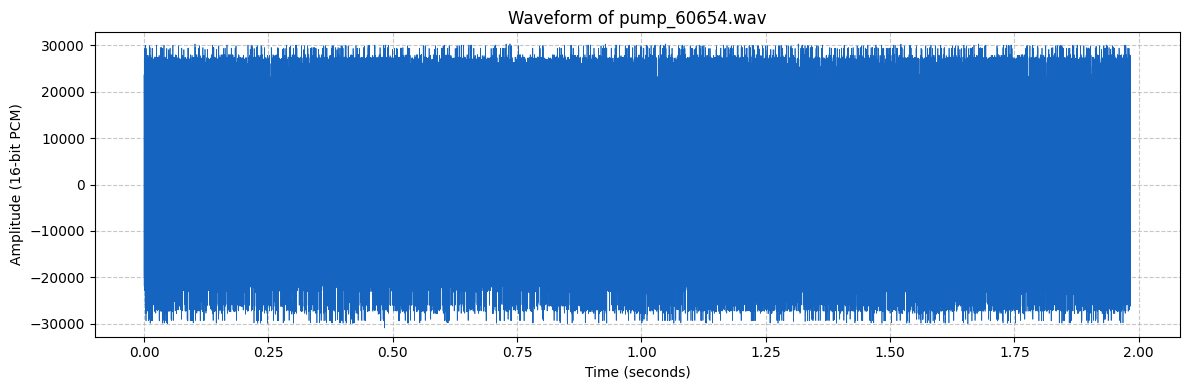

In [12]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import os

WAV_DIR = 'audio_files/wav_dir/'
# TODO: Change this to your NEWEST downloaded file name
filename = "pump_60654.wav" 

filepath = os.path.join(WAV_DIR, filename)

if not os.path.exists(filepath):
    print(f"❌ File not found: {filepath}")
else:
    print(f"Loading {filename}...")
    
    # Read the wav file
    with wave.open(filepath, 'rb') as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        audio_data = wav_file.readframes(n_frames)
        
        # Convert raw bytes to a numpy array of 16-bit integers
        audio_array = np.frombuffer(audio_data, dtype=np.int16)
        
        # Create a time axis in seconds
        time_axis = np.linspace(0, n_frames / sample_rate, num=n_frames)
        
        # Plot the waveform
        plt.figure(figsize=(12, 4))
        plt.plot(time_axis, audio_array, color='#1565c0', linewidth=0.5)
        
        plt.title(f"Waveform of {filename}")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude (16-bit PCM)")
        
        # 16-bit audio ranges from -32768 to 32767
        plt.ylim(-32768, 32767) 
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        print("Displaying waveform...")
        plt.show()